In [2]:
# ================================
# CELL 1: Import Required Libraries
# ================================
# This cell imports all the Python libraries we need for data analysis and visualization

import pandas as pd                    # For working with data tables (like Excel but in Python)
import numpy as np                     # For mathematical operations and handling numbers
import matplotlib.pyplot as plt       # For creating basic plots and charts
import seaborn as sns                  # For creating beautiful, professional-looking plots
from collections import Counter       # For counting how many times something appears
import ast                            # For converting text that looks like lists into actual lists
import warnings                       # For hiding unnecessary warning messages

# Set up the plotting style to make our charts look professional
plt.style.use('default')              # Use matplotlib's default clean style
sns.set_palette("husl")               # Use a colorful, distinct color palette
warnings.filterwarnings('ignore')     # Hide warning messages that might clutter output

# Configure plot settings for better readability
plt.rcParams['figure.figsize'] = (12, 8)    # Make plots larger by default
plt.rcParams['font.size'] = 12               # Make text bigger and easier to read
plt.rcParams['axes.titlesize'] = 14          # Make chart titles larger
plt.rcParams['axes.labelsize'] = 12          # Make axis labels clear


In [3]:
# ================================
# CELL 2: Load the Classified Data
# ================================
# This cell loads the output from your classification script (classify_innovations.py)
# This file contains all the heat pump documents with their assigned categories

# Load the CSV file that contains your classified heat pump innovations
# Replace 'your_file_path' with the actual path to your output file
file_path = "/home/pascualdiego/projects/DiscoveryHP/inputs/heat_pump_data_w_categories.csv"  # UPDATE THIS PATH!

try:
    # Read the CSV file into a pandas DataFrame (think of it as an Excel spreadsheet in Python)
    df = pd.read_csv(file_path)
    
    print(f"✅ Data loaded successfully!")
    print(f"📋 Dataset contains {len(df)} documents")
    print(f"📊 Dataset has {len(df.columns)} columns")
    
    # Show the first few rows to understand our data structure
    print("\n🔍 First 3 rows of data:")
    print(df.head(3))
    
    # Show what columns we have available
    print("\n📝 Available columns:")
    for i, column in enumerate(df.columns, 1):
        print(f"{i:2d}. {column}")
        
except FileNotFoundError:
    print("❌ Error: Could not find the data file!")
    print("💡 Please check the file path and make sure the file exists")
    print("📁 Current expected path:", file_path)

✅ Data loaded successfully!
📋 Dataset contains 528 documents
📊 Dataset has 13 columns

🔍 First 3 rows of data:
               id   source                                     title_abstract  \
0  CN-222157138-U  patents  TITLE: a valve plate structure of an automobil...   
1  CN-213040750-U  patents  TITLE: double-boiling-pot type heat pump water...   
2  CN-110965257-B  patents  TITLE: magnetic heat pump, washing and drying ...   

  is_heat_pump  confidence                                             reason  \
0          yes        0.90  The document discusses a valve plate structure...   
1          yes        0.95  The document is primarily about a specific typ...   
2          yes        0.95  The document primarily discusses a magnetic he...   

  application_type                       specific_applications  \
0          unclear  ['heating in low-temperature environment']   
1         domestic                           ['water heating']   
2         domestic                       

In [4]:
# ================================
# CELL 3: Explore the Data Structure
# ================================
# This cell helps us understand what data we have and how it's organized
# We need to understand the structure before we can create visualizations

print("🔍 EXPLORING DATA STRUCTURE FOR PLOTTING")
print("=" * 50)

# Check the basic information about our dataset
print(f"📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📅 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data Quality Validation
print(f"\n🔍 DATA QUALITY VALIDATION:")
print("-" * 30)

# Check for missing values
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
missing_percentage = (total_missing / (len(df) * len(df.columns))) * 100

print(f"📋 Missing Value Analysis:")
print(f"   Total missing values: {total_missing}")
print(f"   Missing data percentage: {missing_percentage:.2f}%")

if total_missing > 0:
   print(f"\n📝 Missing values by column:")
   for column, missing_count in missing_values.items():
       if missing_count > 0:
           missing_pct = (missing_count / len(df)) * 100
           print(f"   {column}: {missing_count} ({missing_pct:.1f}%)")
else:
   print("   ✅ No missing values found!")

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_pct = (duplicate_count / len(df)) * 100
print(f"\n📋 Duplicate Analysis:")
print(f"   Duplicate rows: {duplicate_count} ({duplicate_pct:.1f}%)")

# Check for duplicate IDs
id_duplicates = df['id'].duplicated().sum()
print(f"   Duplicate IDs: {id_duplicates}")

# Data type validation
print(f"\n📋 Data Types:")
for column in df.columns:
   dtype = df[column].dtype
   unique_count = df[column].nunique()
   print(f"   {column}: {dtype} ({unique_count} unique values)")

# Category-specific validation
print(f"\n📋 Category Field Validation:")
category_fields = ['trad_components', 'non_trad_technologies', 'system_design', 'circular_economy']
for field in category_fields:
   if field in df.columns:
       empty_count = (df[field] == '[]').sum()
       na_count = df[field].isnull().sum()
       print(f"   {field}: {empty_count} empty lists, {na_count} null values")

print("\n📋 KEY COLUMNS FOR INNOVATION ANALYSIS:")
print("-" * 40)

# These are the columns from your classification script that contain category information
category_columns = [
   'trad_components',           # Traditional heat pump components
   'non_trad_technologies',     # Non-traditional technologies  
   'system_design',             # System design aspects
   'circular_economy',          # Circular economy principles
   'application_type',          # Application context
   'technology_readiness_level' # TRL assessment
]

# Check which of these columns actually exist in our data
available_columns = []
for col in category_columns:
   if col in df.columns:
       available_columns.append(col)
       print(f"✅ {col}")
       
       # Show a sample of what's in this column
       sample_value = df[col].dropna().iloc[0] if not df[col].dropna().empty else "No data"
       print(f"   📝 Sample: {str(sample_value)[:100]}...")
       print()
   else:
       print(f"❌ {col} - Not found in dataset")
       
if 'technology_readiness_level' in df.columns:
   print(f"✅ technology_readiness_level")
   trl_sample = df['technology_readiness_level'].dropna().iloc[0] if not df['technology_readiness_level'].dropna().empty else "No data"
   print(f"   📝 Sample: {trl_sample}")
   
   # Show TRL distribution
   trl_counts = df['technology_readiness_level'].value_counts()
   print(f"   📊 TRL Distribution: {dict(trl_counts.head())}")
   print()        

print(f"\n📊 We have {len(available_columns)} category columns available for analysis")

# Final data quality summary
print(f"\n🎯 DATA QUALITY SUMMARY:")
print("-" * 25)
quality_score = 100 - missing_percentage - (duplicate_pct * 0.5)  # Slight penalty for duplicates
print(f"📈 Overall data quality score: {quality_score:.1f}/100")

if quality_score >= 95:
   print("✅ Excellent data quality - ready for analysis")
elif quality_score >= 85:
   print("✅ Good data quality - minor issues but suitable for analysis")
elif quality_score >= 70:
   print("⚠️ Moderate data quality - consider cleaning before analysis")
else:
   print("❌ Poor data quality - cleaning required before analysis")

print(f"📊 Dataset ready for visualization pipeline")

🔍 EXPLORING DATA STRUCTURE FOR PLOTTING
📊 Dataset shape: 528 rows × 13 columns
📅 Memory usage: 1.14 MB

🔍 DATA QUALITY VALIDATION:
------------------------------
📋 Missing Value Analysis:
   Total missing values: 0
   Missing data percentage: 0.00%
   ✅ No missing values found!

📋 Duplicate Analysis:
   Duplicate rows: 0 (0.0%)
   Duplicate IDs: 0

📋 Data Types:
   id: object (528 unique values)
   source: object (2 unique values)
   title_abstract: object (528 unique values)
   is_heat_pump: object (1 unique values)
   confidence: float64 (4 unique values)
   reason: object (523 unique values)
   application_type: object (4 unique values)
   specific_applications: object (407 unique values)
   trad_components: object (17 unique values)
   non_trad_technologies: object (10 unique values)
   system_design: object (8 unique values)
   circular_economy: object (7 unique values)
   technology_readiness_level: object (12 unique values)

📋 Category Field Validation:
   trad_components: 42 em

In [5]:
# ================================
# CELL 4: Data Preprocessing for Category Analysis
# ================================
# This cell cleans and prepares the data for visualization
# We need to convert the text-based category assignments into countable data

print("🔧 PREPROCESSING DATA FOR CATEGORY ANALYSIS")
print("=" * 50)

def safe_eval_list(value):
    """
    Safely convert string representations of lists into actual Python lists
    This handles the category data that comes from your LLM classification
    """
    if pd.isna(value) or value == '' or value == 'nan':
        return []  # Return empty list for missing data
    
    if isinstance(value, str):
        # Try to convert string like "['item1', 'item2']" into actual list
        try:
            # Remove extra whitespace and quotes that might cause issues
            cleaned_value = value.strip().strip('"\'')
            if cleaned_value.startswith('[') and cleaned_value.endswith(']'):
                return ast.literal_eval(cleaned_value)
            else:
                # If it's just a single item, make it a list
                return [cleaned_value]
        except:
            # If conversion fails, treat as a single item
            return [str(value)]
    
    if isinstance(value, list):
        return value  # Already a list, keep as is
    
    return [str(value)]  # Convert anything else to a single-item list

# Apply the cleaning function to all category columns
print("🧹 Cleaning category columns...")
for col in ['trad_components', 'non_trad_technologies', 'system_design', 'circular_economy']:
    if col in df.columns:
        df[f'{col}_clean'] = df[col].apply(safe_eval_list)
        print(f"✅ Cleaned {col}")
        
        # Show how many documents have items in this category
        has_items = df[f'{col}_clean'].apply(len) > 0
        count_with_items = has_items.sum()
        print(f"   📊 {count_with_items} documents ({count_with_items/len(df)*100:.1f}%) have {col}")

print("\n✅ Data preprocessing completed!")

🔧 PREPROCESSING DATA FOR CATEGORY ANALYSIS
🧹 Cleaning category columns...
✅ Cleaned trad_components
   📊 486 documents (92.0%) have trad_components
✅ Cleaned non_trad_technologies
   📊 30 documents (5.7%) have non_trad_technologies
✅ Cleaned system_design
   📊 374 documents (70.8%) have system_design
✅ Cleaned circular_economy
   📊 48 documents (9.1%) have circular_economy

✅ Data preprocessing completed!


In [6]:
# ================================
# CELL 5: Create Innovation Category Distribution Data
# ================================
# This cell counts how many documents fall into each major innovation category
# This gives us the data we need for Plot 1

print("📊 CREATING INNOVATION CATEGORY DISTRIBUTION")
print("=" * 50)

# Initialize a dictionary to count documents in each major category
category_counts = {
    'Traditional Heat Pump Components': 0,
    'Non-traditional Technologies': 0,
    'System Design': 0,
    'Circular Economy': 0,
    'Other Improvements': 0  # We'll combine some categories here
}

# Count documents that mention each category type
print("🔢 Counting documents by innovation category...")

# Traditional components
if 'trad_components_clean' in df.columns:
    traditional_count = (df['trad_components_clean'].apply(len) > 0).sum()
    category_counts['Traditional Heat Pump Components'] = traditional_count
    print(f"📈 Traditional Components: {traditional_count} documents")

# Non-traditional technologies
if 'non_trad_technologies_clean' in df.columns:
    non_trad_count = (df['non_trad_technologies_clean'].apply(len) > 0).sum()
    category_counts['Non-traditional Technologies'] = non_trad_count
    print(f"🚀 Non-traditional Technologies: {non_trad_count} documents")

# System design
if 'system_design_clean' in df.columns:
    system_count = (df['system_design_clean'].apply(len) > 0).sum()
    category_counts['System Design'] = system_count
    print(f"⚙️ System Design: {system_count} documents")

# Circular economy
if 'circular_economy_clean' in df.columns:
    circular_count = (df['circular_economy_clean'].apply(len) > 0).sum()
    category_counts['Circular Economy'] = circular_count
    print(f"♻️ Circular Economy: {circular_count} documents")

# Calculate documents with no clear category (for completeness)
documents_with_categories = 0
for key, value in category_counts.items():
    if key != 'Other Improvements':
        documents_with_categories = max(documents_with_categories, value)

# Create a DataFrame for easy plotting
category_df = pd.DataFrame([
    {'Category': category, 'Count': count, 'Percentage': (count/len(df))*100}
    for category, count in category_counts.items()
    if count > 0  # Only include categories that have documents
])

print(f"\n📋 SUMMARY:")
print(f"Total documents analyzed: {len(df)}")
print(f"Categories with data: {len(category_df)}")
print("\nCategory breakdown:")
print(category_df.to_string(index=False))

📊 CREATING INNOVATION CATEGORY DISTRIBUTION
🔢 Counting documents by innovation category...
📈 Traditional Components: 486 documents
🚀 Non-traditional Technologies: 30 documents
⚙️ System Design: 374 documents
♻️ Circular Economy: 48 documents

📋 SUMMARY:
Total documents analyzed: 528
Categories with data: 4

Category breakdown:
                        Category  Count  Percentage
Traditional Heat Pump Components    486   92.045455
    Non-traditional Technologies     30    5.681818
                   System Design    374   70.833333
                Circular Economy     48    9.090909


🎨 CREATING PLOT 1: INNOVATION CATEGORY DISTRIBUTION
✅ Plot 1 created successfully!
💡 This chart shows the relative focus areas in current heat pump R&D
📊 Use this to identify which innovation areas dominate the landscape


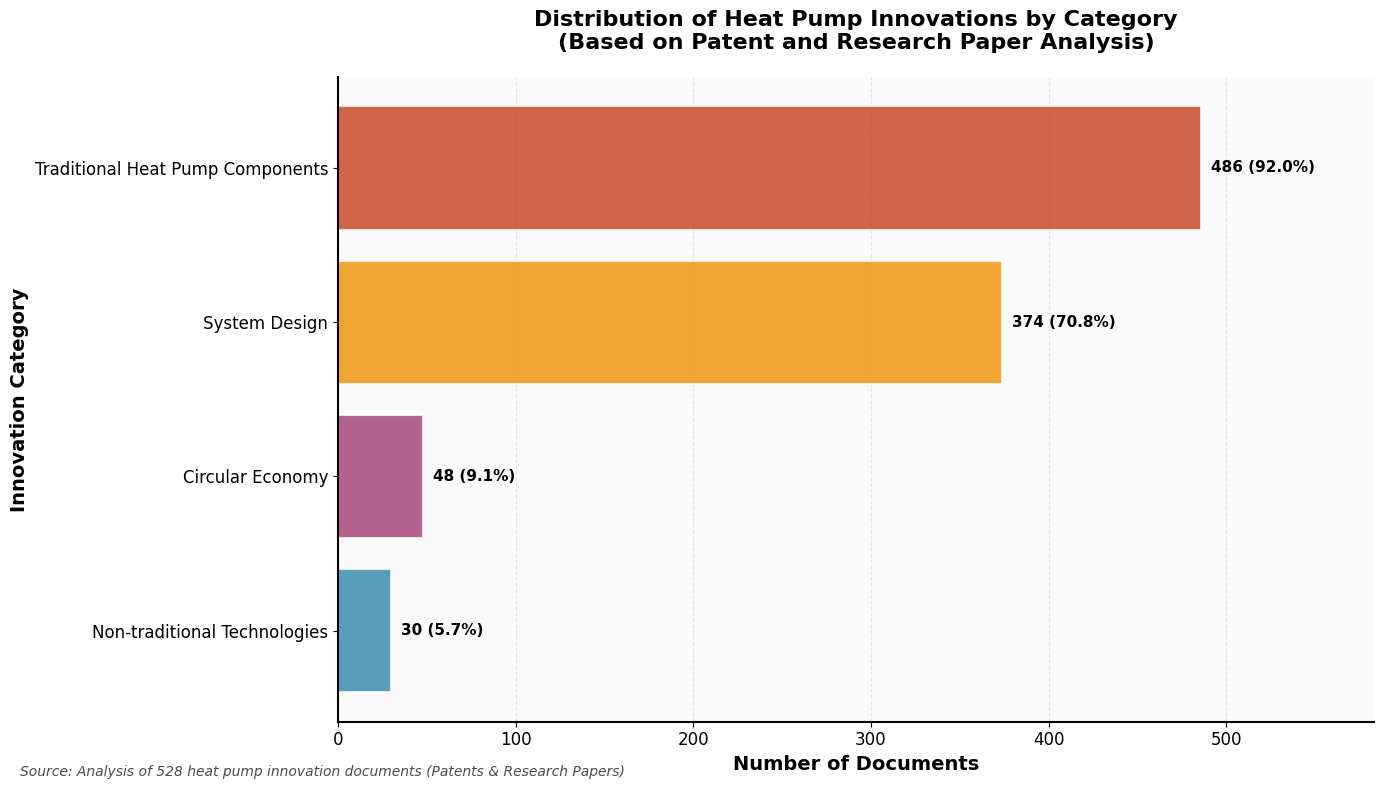

In [7]:
# ================================
# CELL 6: Create Plot 1 - Innovation Category Distribution (Horizontal Bar Chart)
# ================================
# This cell creates the first visualization: a professional horizontal bar chart
# showing the distribution of innovations across major categories

print("🎨 CREATING PLOT 1: INNOVATION CATEGORY DISTRIBUTION")
print("=" * 50)

# Create the figure and axis for our plot
fig, ax = plt.subplots(figsize=(14, 8))

# Sort categories by count (descending) for better visual impact
category_df_sorted = category_df.sort_values('Count', ascending=True)  # True for horizontal bars

# Create horizontal bar chart
bars = ax.barh(category_df_sorted['Category'], 
               category_df_sorted['Count'],
               color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#563E7C'],
               alpha=0.8,
               edgecolor='white',
               linewidth=1.5)

# Customize the plot to make it publication-ready
ax.set_xlabel('Number of Documents', fontsize=14, fontweight='bold')
ax.set_ylabel('Innovation Category', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Heat Pump Innovations by Category\n(Based on Patent and Research Paper Analysis)', 
             fontsize=16, fontweight='bold', pad=20)

# Add value labels on the bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    percentage = category_df_sorted.iloc[i]['Percentage']
    
    # Add count and percentage labels
    ax.text(width + len(df)*0.01,  # Slightly offset from bar end
            bar.get_y() + bar.get_height()/2,  # Center vertically
            f'{int(width)} ({percentage:.1f}%)',
            ha='left', va='center', fontweight='bold', fontsize=11)

# Improve the overall appearance
ax.grid(axis='x', alpha=0.3, linestyle='--')  # Add subtle grid lines
ax.set_axisbelow(True)  # Put grid behind bars
ax.spines['top'].set_visible(False)     # Remove top border
ax.spines['right'].set_visible(False)   # Remove right border
ax.spines['left'].set_linewidth(1.5)    # Thicker left border
ax.spines['bottom'].set_linewidth(1.5)  # Thicker bottom border

# Set x-axis limits with some padding
ax.set_xlim(0, category_df_sorted['Count'].max() * 1.2)

# Add a subtle background color
ax.set_facecolor('#fafafa')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Add source note
plt.figtext(0.02, 0.02, 
           f'Source: Analysis of {len(df)} heat pump innovation documents (Patents & Research Papers)', 
           fontsize=10, style='italic', alpha=0.7)

print("✅ Plot 1 created successfully!")
print("💡 This chart shows the relative focus areas in current heat pump R&D")
print("📊 Use this to identify which innovation areas dominate the landscape")

# Show the plot
plt.show()


In [8]:
# ================================
# CELL 7: Create Alternative Visualization - Treemap
# ================================
# This cell creates an alternative visualization using a treemap
# Treemaps are great for showing proportional relationships

# Note: This requires the squarify library
# If you don't have it, install with: pip install squarify

try:
    import squarify
    
    print("🎨 CREATING ALTERNATIVE VISUALIZATION: TREEMAP")
    print("=" * 50)
    
    # Create treemap
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Prepare data for treemap
    sizes = category_df['Count'].tolist()
    labels = [f"{cat}\n{count} docs\n({pct:.1f}%)" 
              for cat, count, pct in zip(category_df['Category'], 
                                       category_df['Count'], 
                                       category_df['Percentage'])]
    
    # Create color palette
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#563E7C'][:len(sizes)]
    
    # Create the treemap
    squarify.plot(sizes=sizes, 
                  label=labels, 
                  color=colors,
                  alpha=0.8,
                  text_kwargs={'fontsize': 12, 'weight': 'bold'},
                  ax=ax)
    
    ax.set_title('Heat Pump Innovation Categories - Proportional View\n(Alternative Visualization)', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Remove axes for cleaner look
    ax.axis('off')
    
    plt.tight_layout()
    
    print("✅ Treemap created successfully!")
    print("💡 This alternative view shows proportional relationships more intuitively")
    
    plt.show()
    
except ImportError:
    print("📦 Squarify library not available for treemap")
    print("💡 Install with: pip install squarify")
    print("⏭️ Skipping treemap visualization")

📦 Squarify library not available for treemap
💡 Install with: pip install squarify
⏭️ Skipping treemap visualization


In [9]:
# ================================
# CELL 8: Save the Plot and Data
# ================================
# This cell saves our visualizations and data for use in your thesis

import os
from pathlib import Path

print("💾 SAVING PLOT AND DATA FOR THESIS")
print("=" * 50)

# Define the output directory
output_dir = Path("/home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5")

# Create the directory if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)
print(f"📁 Output directory: {output_dir}")

# Define file paths
png_path = output_dir / "chapter5_plot1_innovation_categories.png"
pdf_path = output_dir / "chapter5_plot1_innovation_categories.pdf"
csv_path = output_dir / "chapter5_innovation_category_summary.csv"
summary_path = output_dir / "chapter5_plot1_summary.txt"

# Save the plot in high resolution for thesis inclusion
fig.savefig(png_path, 
            dpi=300,           # High resolution for academic publications
            bbox_inches='tight', # Remove excess whitespace
            facecolor='white',   # White background
            edgecolor='none')    # No border

fig.savefig(pdf_path, 
            bbox_inches='tight', 
            facecolor='white')

print("✅ Plot saved as:")
print(f"   📊 {png_path} (high-res for thesis)")
print(f"   📊 {pdf_path} (vector format)")

# Save the summary data for reference
category_df.to_csv(csv_path, index=False)
print(f"   📋 {csv_path} (data table)")

# Create a summary for your thesis writing
# Get actual percentages from our analysis
trad_pct = category_df[category_df['Category'] == 'Traditional Heat Pump Components']['Percentage'].iloc[0] if 'Traditional Heat Pump Components' in category_df['Category'].values else 0
system_pct = category_df[category_df['Category'] == 'System Design']['Percentage'].iloc[0] if 'System Design' in category_df['Category'].values else 0
circular_pct = category_df[category_df['Category'] == 'Circular Economy']['Percentage'].iloc[0] if 'Circular Economy' in category_df['Category'].values else 0
nonTrad_pct = category_df[category_df['Category'] == 'Non-traditional Technologies']['Percentage'].iloc[0] if 'Non-traditional Technologies' in category_df['Category'].values else 0

# Create adaptive interpretations based on actual percentages
def interpret_percentage(pct, category_name):
    if pct >= 70:
        return f"{category_name} overwhelmingly dominate"
    elif pct >= 50:
        return f"{category_name} represent a major focus"
    elif pct >= 30:
        return f"{category_name} show substantial representation"
    elif pct >= 15:
        return f"{category_name} are moderately represented"
    elif pct >= 5:
        return f"{category_name} show emerging but limited presence"
    else:
        return f"{category_name} are nascent with minimal representation"

# Create interpretations
trad_interp = interpret_percentage(trad_pct, "Traditional components")
system_interp = interpret_percentage(system_pct, "System design innovations") 
circular_interp = interpret_percentage(circular_pct, "Circular economy integration")
nonTrad_interp = interpret_percentage(nonTrad_pct, "Non-traditional technologies")

summary_text = f"""
CHAPTER 5 - PLOT 1 SUMMARY FOR THESIS WRITING:

Dataset: {len(df)} heat pump innovation documents analyzed
Time period: [Add your time period here]
Sources: Patents and research papers

Key Findings:
"""

for _, row in category_df.sort_values('Count', ascending=False).iterrows():
    summary_text += f"- {row['Category']}: {row['Count']} documents ({row['Percentage']:.1f}%)\n"

summary_text += f"""
Insights for Chapter 5:
1. {trad_interp} ({trad_pct:.1f}%)
2. {system_interp} ({system_pct:.1f}%)
3. {circular_interp} ({circular_pct:.1f}%)
4. {nonTrad_interp} ({nonTrad_pct:.1f}%)

Key Thesis Arguments Supported:
- Gap between circular economy theory and heat pump practice is {'clearly evident' if circular_pct < 30 else 'still present but narrowing'}
- Traditional technology optimization {'dominates' if trad_pct > 70 else 'remains significant in'} R&D investment
- Breakthrough technologies are {'in early development phase' if nonTrad_pct < 15 else 'gaining significant momentum'}
- Systems-level thinking is {'gaining traction' if system_pct > 30 else 'emerging'} in the field

Narrative for Chapter 5.1:
The analysis of {len(df)} heat pump innovation documents reveals a field {'in transition' if max(trad_pct, system_pct, circular_pct, nonTrad_pct) < 80 else 'with clear innovation priorities'}. 
{trad_interp} ({trad_pct:.1f}%), while there is {'growing' if system_pct > 30 else 'emerging'} attention to system design approaches ({system_pct:.1f}%) and {'significant' if circular_pct > 30 else 'limited but emerging'} integration 
of circular economy principles ({circular_pct:.1f}%). Non-traditional technologies represent 
{'a significant innovation frontier' if nonTrad_pct > 10 else 'an emerging innovation frontier'} ({nonTrad_pct:.1f}%), suggesting {'substantial' if nonTrad_pct > 10 else 'significant'} potential for 
breakthrough developments.

Next steps: Proceed to Plot 2 (TRL Analysis)
"""

# Save summary
with open(summary_path, 'w') as f:
    f.write(summary_text)

print(f"   📝 {summary_path} (thesis writing notes)")
print("\n✅ All files saved successfully to:")
print(f"📁 {output_dir}")
print("📖 Ready to proceed with narrative writing or next visualization!")

print("\n" + "="*50)
print("🎯 PLOT 1 COMPLETE - INNOVATION CATEGORY DISTRIBUTION")
print("="*50)
print("✅ Visualization created and saved")
print("📊 Data processed and exported") 
print("📝 Summary notes generated for thesis writing")
print("⏭️ Ready for Plot 2: Innovation Timeline Trends")

💾 SAVING PLOT AND DATA FOR THESIS
📁 Output directory: /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5
✅ Plot saved as:
   📊 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_plot1_innovation_categories.png (high-res for thesis)
   📊 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_plot1_innovation_categories.pdf (vector format)
   📋 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_innovation_category_summary.csv (data table)
   📝 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_plot1_summary.txt (thesis writing notes)

✅ All files saved successfully to:
📁 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5
📖 Ready to proceed with narrative writing or next visualization!

🎯 PLOT 1 COMPLETE - INNOVATION CATEGORY DISTRIBUTION
✅ Visualization created and saved
📊 Data processed and exported
📝 Summary notes generated for thesis writing
⏭️ Ready for Plot 2: Innovation Timeline Trends


In [10]:
# ================================
# CELL 9: Explore TRL Data Distribution (FIXED)
# ================================
print("\n" + "="*50)
print("🔍 EXPLORING TRL DATA FOR PLOT 2")
print("="*50)

# Check if TRL column exists
if 'technology_readiness_level' in df.columns:
    print("✅ Technology Readiness Level data found!")
    
    # Basic TRL data overview - USE DIFFERENT VARIABLE NAMES
    dataset_size = len(df)  # CHANGED: avoid collision with total_docs
    trl_available = df['technology_readiness_level'].notna().sum()
    trl_missing = dataset_size - trl_available
    
    print(f"📊 TRL Data Overview:")
    print(f"   Total documents: {dataset_size}")
    print(f"   Documents with TRL data: {trl_available} ({trl_available/dataset_size*100:.1f}%)")
    print(f"   Documents missing TRL: {trl_missing} ({trl_missing/dataset_size*100:.1f}%)")
    
    # Show TRL distribution
    print(f"\n📋 TRL Distribution:")
    trl_counts = df['technology_readiness_level'].value_counts(dropna=False)
    print(trl_counts)
    
    # Show some sample TRL values
    print(f"\n🔍 Sample TRL entries:")
    trl_samples = df['technology_readiness_level'].dropna().head(10)
    for i, trl in enumerate(trl_samples, 1):
        print(f"   {i}. {trl}")
    
    # Analyze TRL by innovation category
    print(f"\n📊 TRL BY INNOVATION CATEGORY:")
    print("-" * 40)
    
    # Traditional components
    if 'trad_components_clean' in df.columns:
        trad_docs = df[df['trad_components_clean'].apply(len) > 0]
        trad_trl = trad_docs['technology_readiness_level'].value_counts(dropna=False)
        print(f"🔧 Traditional Components TRL ({len(trad_docs)} docs):")
        for trl, count in trad_trl.head().items():
            print(f"   {trl}: {count} docs ({count/len(trad_docs)*100:.1f}%)")
        print()
    
    # Non-traditional technologies
    if 'non_trad_technologies_clean' in df.columns:
        nonTrad_docs = df[df['non_trad_technologies_clean'].apply(len) > 0]
        if len(nonTrad_docs) > 0:
            nonTrad_trl = nonTrad_docs['technology_readiness_level'].value_counts(dropna=False)
            print(f"🚀 Non-traditional Technologies TRL ({len(nonTrad_docs)} docs):")
            for trl, count in nonTrad_trl.head().items():
                print(f"   {trl}: {count} docs ({count/len(nonTrad_docs)*100:.1f}%)")
            print()
    
    # System design
    if 'system_design_clean' in df.columns:
        system_docs = df[df['system_design_clean'].apply(len) > 0]
        if len(system_docs) > 0:
            system_trl = system_docs['technology_readiness_level'].value_counts(dropna=False)
            print(f"⚙️ System Design TRL ({len(system_docs)} docs):")
            for trl, count in system_trl.head().items():
                print(f"   {trl}: {count} docs ({count/len(system_docs)*100:.1f}%)")
            print()
    
    # Circular economy
    if 'circular_economy_clean' in df.columns:
        circular_docs = df[df['circular_economy_clean'].apply(len) > 0]
        if len(circular_docs) > 0:
            circular_trl = circular_docs['technology_readiness_level'].value_counts(dropna=False)
            print(f"♻️ Circular Economy TRL ({len(circular_docs)} docs):")
            for trl, count in circular_trl.head().items():
                print(f"   {trl}: {count} docs ({count/len(circular_docs)*100:.1f}%)")
            print()
    
    # TRL cleaning function
    def extract_trl_number(trl_value):
        """Extract numerical TRL from text like 'TRL 6' or just '6'"""
        if pd.isna(trl_value):
            return 'Missing'
        
        trl_str = str(trl_value).strip().lower()
        
        if 'unclear' in trl_str or 'unknown' in trl_str:
            return 'Unclear'
        
        # Try to extract number
        import re
        numbers = re.findall(r'\d+', trl_str)
        if numbers:
            trl_num = int(numbers[0])
            if 1 <= trl_num <= 9:
                return f'TRL {trl_num}'
        
        return 'Other'
    
    # Apply TRL cleaning
    df['trl_clean'] = df['technology_readiness_level'].apply(extract_trl_number)
    
    print(f"🧹 CLEANED TRL DISTRIBUTION:")
    print("-" * 30)
    trl_clean_counts = df['trl_clean'].value_counts()
    for trl, count in trl_clean_counts.items():
        print(f"   {trl}: {count} docs ({count/dataset_size*100:.1f}%)")
    
    # Check feasibility
    numerical_trls = trl_clean_counts[trl_clean_counts.index.str.startswith('TRL')].sum()
    print(f"\n📈 PLOT 2 FEASIBILITY:")
    print(f"   Documents with numerical TRL (1-9): {numerical_trls}")
    print(f"   Documents with 'Unclear' TRL: {trl_clean_counts.get('Unclear', 0)}")
    
    if numerical_trls >= 50:
        print("   ✅ Excellent data for TRL heatmap visualization!")
    elif numerical_trls >= 20:
        print("   ✅ Good data for TRL analysis - proceed with visualization")
    else:
        print("   ⚠️ Limited numerical TRL data - consider alternative visualization")
    
    print("\n🎨 Ready to create Plot 2: TRL Analysis!")
    
else:
    print("❌ No 'technology_readiness_level' column found in dataset")
    print("💡 Check if your classification script includes TRL assessment")
    print("⏭️ Skip to next plot or add TRL data")


🔍 EXPLORING TRL DATA FOR PLOT 2
✅ Technology Readiness Level data found!
📊 TRL Data Overview:
   Total documents: 528
   Documents with TRL data: 528 (100.0%)
   Documents missing TRL: 0 (0.0%)

📋 TRL Distribution:
technology_readiness_level
unclear    373
TRL 6       85
TRL 8       27
6           16
TRL 5       12
TRL 7        4
8            3
TRL 4        3
TRL 9        2
9            1
7            1
5            1
Name: count, dtype: int64

🔍 Sample TRL entries:
   1. unclear
   2. unclear
   3. TRL 6
   4. unclear
   5. unclear
   6. unclear
   7. unclear
   8. unclear
   9. TRL 6
   10. unclear

📊 TRL BY INNOVATION CATEGORY:
----------------------------------------
🔧 Traditional Components TRL (486 docs):
   unclear: 338 docs (69.5%)
   TRL 6: 82 docs (16.9%)
   TRL 8: 26 docs (5.3%)
   6: 14 docs (2.9%)
   TRL 5: 12 docs (2.5%)

🚀 Non-traditional Technologies TRL (30 docs):
   unclear: 20 docs (66.7%)
   TRL 6: 6 docs (20.0%)
   6: 3 docs (10.0%)
   9: 1 docs (3.3%)

⚙️ System 

In [11]:
# ================================
# CELL 10: Prepare TRL Analysis Data for Plot 2 (FIXED)
# ================================
print("\n" + "="*50)
print("🔧 PREPARING TRL ANALYSIS DATA FOR PLOT 2")
print("="*50)

# Define GLOBAL constants that won't be overwritten
TOTAL_DOCUMENTS = len(df)
TRL_AVAILABLE = df['technology_readiness_level'].notna().sum()
UNCLEAR_COUNT = (df['trl_clean'] == 'Unclear').sum()
NUMERICAL_TRL_COUNT = (df['trl_clean'].str.startswith('TRL')).sum()

print(f"📊 Working with {TOTAL_DOCUMENTS} total documents")
print(f"📋 {NUMERICAL_TRL_COUNT} documents have numerical TRL data ({NUMERICAL_TRL_COUNT/TOTAL_DOCUMENTS*100:.1f}%)")
print(f"⚠️ {UNCLEAR_COUNT} documents have unclear TRL ({UNCLEAR_COUNT/TOTAL_DOCUMENTS*100:.1f}%)")

# Create TRL-Category matrix for heatmap
print(f"\n🔥 CREATING TRL-CATEGORY HEATMAP DATA:")
print("-" * 40)

# Define categories and TRL levels
CATEGORIES = ['Traditional Components', 'Non-traditional Technologies', 'System Design', 'Circular Economy']
TRL_LEVELS = ['TRL 1', 'TRL 2', 'TRL 3', 'TRL 4', 'TRL 5', 'TRL 6', 'TRL 7', 'TRL 8', 'TRL 9']

# Initialize matrix
trl_matrix = pd.DataFrame(0, index=CATEGORIES, columns=TRL_LEVELS)

# Function to get documents for each category
def get_category_documents(category_name):
    """Get documents for a specific category - RENAMED to avoid conflicts"""
    if category_name == 'Traditional Components':
        return df[df['trad_components_clean'].apply(len) > 0]
    elif category_name == 'Non-traditional Technologies':
        return df[df['non_trad_technologies_clean'].apply(len) > 0]
    elif category_name == 'System Design':
        return df[df['system_design_clean'].apply(len) > 0]
    elif category_name == 'Circular Economy':
        return df[df['circular_economy_clean'].apply(len) > 0]
    return pd.DataFrame()

# Fill the matrix
print("📋 Populating TRL matrix by category:")
category_document_counts = {}  # RENAMED to avoid collision

for category in CATEGORIES:
    cat_docs = get_category_documents(category)
    cat_total = len(cat_docs)
    category_document_counts[category] = cat_total  # Store for later use
    
    if cat_total > 0:
        print(f"\n🔍 {category} ({cat_total} documents):")
        
        for trl_level in TRL_LEVELS:
            count = (cat_docs['trl_clean'] == trl_level).sum()
            trl_matrix.loc[category, trl_level] = count
            
            if count > 0:
                percentage = count / cat_total * 100
                print(f"   {trl_level}: {count} docs ({percentage:.1f}%)")

print(f"\n📊 TRL MATRIX SUMMARY:")
print("=" * 30)
print(trl_matrix)

# Calculate metrics
print(f"\n📈 MATRIX STATISTICS:")
print("-" * 20)

# Document counts per category
for category in CATEGORIES:
    count = category_document_counts[category]
    print(f"{category}: {count} total documents")

# TRL coverage per category
print(f"\nTRL Coverage (numerical TRLs only):")
for category in CATEGORIES:
    total_in_cat = category_document_counts[category]
    numerical_in_cat = trl_matrix.loc[category].sum()
    coverage = numerical_in_cat / total_in_cat * 100 if total_in_cat > 0 else 0
    print(f"{category}: {numerical_in_cat}/{total_in_cat} ({coverage:.1f}%)")

# Calculate average TRL by category
category_average_trl = {}
for category in CATEGORIES:
    row = trl_matrix.loc[category]
    if row.sum() > 0:
        # Calculate weighted average TRL (1-9)
        weighted_sum = sum(int(trl.split()[1]) * count for trl, count in row.items() if count > 0)
        total_docs_in_cat = row.sum()
        avg_trl = weighted_sum / total_docs_in_cat
        category_average_trl[category] = avg_trl
        print(f"📊 {category} avg TRL: {avg_trl:.1f}")

print(f"\n✅ Data preparation complete!")
print(f"📊 Ready to create TRL heatmap with {len(CATEGORIES)} categories × {len(TRL_LEVELS)} TRL levels")
print(f"🎯 Matrix contains {trl_matrix.sum().sum()} total TRL assignments")


🔧 PREPARING TRL ANALYSIS DATA FOR PLOT 2
📊 Working with 528 total documents
📋 155 documents have numerical TRL data (29.4%)
⚠️ 373 documents have unclear TRL (70.6%)

🔥 CREATING TRL-CATEGORY HEATMAP DATA:
----------------------------------------
📋 Populating TRL matrix by category:

🔍 Traditional Components (486 documents):
   TRL 4: 2 docs (0.4%)
   TRL 5: 13 docs (2.7%)
   TRL 6: 96 docs (19.8%)
   TRL 7: 5 docs (1.0%)
   TRL 8: 29 docs (6.0%)
   TRL 9: 3 docs (0.6%)

🔍 Non-traditional Technologies (30 documents):
   TRL 6: 9 docs (30.0%)
   TRL 9: 1 docs (3.3%)

🔍 System Design (374 documents):
   TRL 4: 2 docs (0.5%)
   TRL 5: 12 docs (3.2%)
   TRL 6: 97 docs (25.9%)
   TRL 7: 5 docs (1.3%)
   TRL 8: 26 docs (7.0%)
   TRL 9: 2 docs (0.5%)

🔍 Circular Economy (48 documents):
   TRL 4: 1 docs (2.1%)
   TRL 5: 4 docs (8.3%)
   TRL 6: 21 docs (43.8%)
   TRL 7: 3 docs (6.2%)
   TRL 8: 6 docs (12.5%)
   TRL 9: 2 docs (4.2%)

📊 TRL MATRIX SUMMARY:
                              TRL 1  TRL


🎨 CREATING PLOT 2: TRL ANALYSIS HEATMAP
🔍 DEBUG CHECK:
   TOTAL_DOCUMENTS = 528
   NUMERICAL_TRL_COUNT = 155
   len(df) = 528
   Coverage calculation: 29.4%

🔥 Creating TRL distribution heatmap...
📊 Creating TRL coverage analysis...
✅ Plot 2 created successfully!

💡 KEY INSIGHTS FROM TRL ANALYSIS:
-----------------------------------
🎯 TRL 6 dominance: 101 documents (65.2% of numerical TRLs)
📊 Highest TRL coverage: Circular Economy (77.1%)
📊 Lowest TRL coverage: Traditional Components (30.5%)
🚀 Commercial-ready technologies (TRL 8-9): 33 documents
🔬 Early-stage research (TRL 1-4): 3 documents
♻️ Circular Economy maturity: 11/37 docs are TRL 7+ (29.7%)

📊 Ready for thesis interpretation!


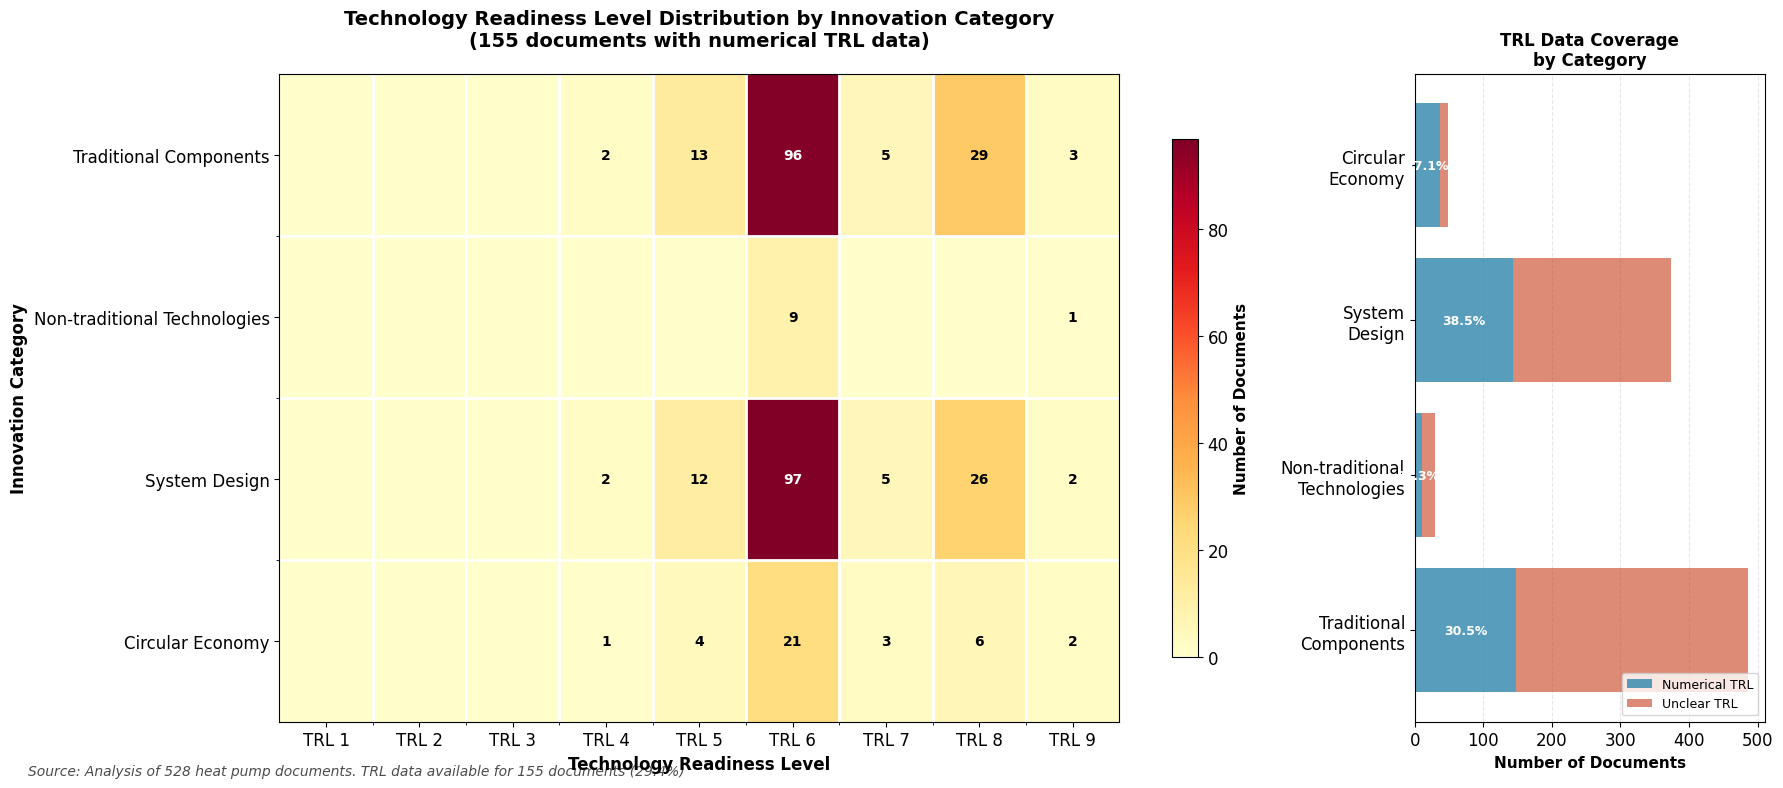

In [12]:
# ================================
# CELL 11: Create Plot 2 - TRL Analysis Heatmap (FIXED)
# ================================
print("\n" + "="*50)
print("🎨 CREATING PLOT 2: TRL ANALYSIS HEATMAP")
print("="*50)

# Debug check with CONSTANTS
print(f"🔍 DEBUG CHECK:")
print(f"   TOTAL_DOCUMENTS = {TOTAL_DOCUMENTS}")
print(f"   NUMERICAL_TRL_COUNT = {NUMERICAL_TRL_COUNT}")
print(f"   len(df) = {len(df)}")
print(f"   Coverage calculation: {NUMERICAL_TRL_COUNT/TOTAL_DOCUMENTS*100:.1f}%")
print()

# Create the TRL heatmap visualization - SINGLE CREATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [3, 1]})

# Main heatmap (left subplot)
print("🔥 Creating TRL distribution heatmap...")

# Create heatmap with custom colormap
im = ax1.imshow(trl_matrix.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# Set labels and ticks
ax1.set_xticks(range(len(TRL_LEVELS)))
ax1.set_xticklabels(TRL_LEVELS, rotation=0, ha='center')
ax1.set_yticks(range(len(CATEGORIES)))
ax1.set_yticklabels(CATEGORIES)

# Add value annotations on heatmap
for i in range(len(CATEGORIES)):
    for j in range(len(TRL_LEVELS)):
        value = trl_matrix.iloc[i, j]
        if value > 0:
            # Use white text for dark cells, black for light cells
            text_color = 'white' if value > trl_matrix.values.max() * 0.5 else 'black'
            ax1.text(j, i, str(value), ha='center', va='center', 
                    color=text_color, fontweight='bold', fontsize=10)

# Customize main heatmap
ax1.set_title('Technology Readiness Level Distribution by Innovation Category\n' + 
              f'({NUMERICAL_TRL_COUNT} documents with numerical TRL data)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Technology Readiness Level', fontsize=12, fontweight='bold')
ax1.set_ylabel('Innovation Category', fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax1, shrink=0.8)
cbar.set_label('Number of Documents', fontsize=11, fontweight='bold')

# Add grid lines
ax1.set_xticks([x-0.5 for x in range(1, len(TRL_LEVELS))], minor=True)
ax1.set_yticks([y-0.5 for y in range(1, len(CATEGORIES))], minor=True)
ax1.grid(which='minor', color='white', linewidth=2)

# Coverage analysis (right subplot)
print("📊 Creating TRL coverage analysis...")

# Calculate coverage data using CONSTANTS
coverage_data = []
for category in CATEGORIES:
    total_in_cat = category_document_counts[category]
    numerical_in_cat = trl_matrix.loc[category].sum()
    unclear_in_cat = total_in_cat - numerical_in_cat
    
    coverage_data.append({
        'Category': category.replace(' ', '\n'),
        'Numerical TRL': numerical_in_cat,
        'Unclear TRL': unclear_in_cat,
        'Coverage %': numerical_in_cat / total_in_cat * 100
    })

coverage_df = pd.DataFrame(coverage_data)

# Create stacked bar chart
y_pos = range(len(CATEGORIES))
ax2.barh(y_pos, coverage_df['Numerical TRL'], 
         label='Numerical TRL', color='#2E86AB', alpha=0.8)
ax2.barh(y_pos, coverage_df['Unclear TRL'], 
         left=coverage_df['Numerical TRL'],
         label='Unclear TRL', color='#C73E1D', alpha=0.6)

# Add percentage labels
for i, row in coverage_df.iterrows():
    if row['Numerical TRL'] > 0:
        ax2.text(row['Numerical TRL']/2, i, f"{row['Coverage %']:.1f}%", 
                ha='center', va='center', fontweight='bold', fontsize=9, color='white')

# Customize coverage chart
ax2.set_yticks(y_pos)
ax2.set_yticklabels([cat.replace(' ', '\n') for cat in CATEGORIES])
ax2.set_xlabel('Number of Documents', fontsize=11, fontweight='bold')
ax2.set_title('TRL Data Coverage\nby Category', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Overall plot adjustments
plt.tight_layout()

# Add source note with CONSTANTS
fig.text(0.02, 0.02, 
         f'Source: Analysis of {TOTAL_DOCUMENTS} heat pump documents. TRL data available for {NUMERICAL_TRL_COUNT} documents ({NUMERICAL_TRL_COUNT/TOTAL_DOCUMENTS*100:.1f}%)', 
         fontsize=10, style='italic', alpha=0.7)

print("✅ Plot 2 created successfully!")

# Generate insights using CONSTANTS
print(f"\n💡 KEY INSIGHTS FROM TRL ANALYSIS:")
print("-" * 35)

# TRL 6 dominance
trl6_unique_docs = (df['trl_clean'] == 'TRL 6').sum()
trl6_percentage = trl6_unique_docs / NUMERICAL_TRL_COUNT * 100
print(f"🎯 TRL 6 dominance: {trl6_unique_docs} documents ({trl6_percentage:.1f}% of numerical TRLs)")

# Coverage insights
highest_coverage = coverage_df.loc[coverage_df['Coverage %'].idxmax()]
lowest_coverage = coverage_df.loc[coverage_df['Coverage %'].idxmin()]
print(f"📊 Highest TRL coverage: {highest_coverage['Category'].replace(chr(10), ' ')} ({highest_coverage['Coverage %']:.1f}%)")
print(f"📊 Lowest TRL coverage: {lowest_coverage['Category'].replace(chr(10), ' ')} ({lowest_coverage['Coverage %']:.1f}%)")

# Maturity insights
mature_technologies = ((df['trl_clean'] == 'TRL 8') | (df['trl_clean'] == 'TRL 9')).sum()
early_stage = ((df['trl_clean'] == 'TRL 1') | (df['trl_clean'] == 'TRL 2') | 
               (df['trl_clean'] == 'TRL 3') | (df['trl_clean'] == 'TRL 4')).sum()
print(f"🚀 Commercial-ready technologies (TRL 8-9): {mature_technologies} documents")
print(f"🔬 Early-stage research (TRL 1-4): {early_stage} documents")

# Circular Economy insights
circular_economy_docs = df[df['circular_economy_clean'].apply(len) > 0]
circular_economy_high_trl = ((circular_economy_docs['trl_clean'] == 'TRL 7') | 
                            (circular_economy_docs['trl_clean'] == 'TRL 8') | 
                            (circular_economy_docs['trl_clean'] == 'TRL 9')).sum()
ce_numerical_total = (circular_economy_docs['trl_clean'].str.startswith('TRL')).sum()
ce_mature_percentage = circular_economy_high_trl / ce_numerical_total * 100 if ce_numerical_total > 0 else 0

print(f"♻️ Circular Economy maturity: {circular_economy_high_trl}/{ce_numerical_total} docs are TRL 7+ ({ce_mature_percentage:.1f}%)")
print(f"\n📊 Ready for thesis interpretation!")

# Show the plot
plt.show()

In [13]:
# ================================
# CELL 12: Save Plot 2 and Analysis (FIXED)
# ================================
print("\n" + "="*50)
print("💾 SAVING PLOT 2: TRL ANALYSIS")
print("="*50)

# Debug check with CONSTANTS - should all be correct now
print(f"🔍 FINAL DEBUG CHECK:")
print(f"   TOTAL_DOCUMENTS = {TOTAL_DOCUMENTS}")
print(f"   NUMERICAL_TRL_COUNT = {NUMERICAL_TRL_COUNT}")
print(f"   UNCLEAR_COUNT = {UNCLEAR_COUNT}")
print(f"   len(df) = {len(df)}")
print(f"   Coverage: {NUMERICAL_TRL_COUNT/TOTAL_DOCUMENTS*100:.1f}%")
print()

# Use the same output directory as Plot 1
output_dir = Path("/home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5")

# Define file paths for Plot 2
png_path_plot2 = output_dir / "chapter5_plot2_trl_analysis.png"
pdf_path_plot2 = output_dir / "chapter5_plot2_trl_analysis.pdf"
csv_path_plot2 = output_dir / "chapter5_trl_matrix_data.csv"
summary_path_plot2 = output_dir / "chapter5_plot2_summary.txt"

# Save the plot
fig.savefig(png_path_plot2, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
fig.savefig(pdf_path_plot2, bbox_inches='tight', facecolor='white')

print("✅ Plot 2 saved as:")
print(f"   📊 {png_path_plot2} (high-res for thesis)")
print(f"   📊 {pdf_path_plot2} (vector format)")

# Save the TRL matrix data
trl_matrix.to_csv(csv_path_plot2)
print(f"   📋 {csv_path_plot2} (TRL matrix data)")

# Calculate metrics using CONSTANTS
trl6_unique_docs = (df['trl_clean'] == 'TRL 6').sum()
trl6_percentage = (trl6_unique_docs / NUMERICAL_TRL_COUNT * 100) if NUMERICAL_TRL_COUNT > 0 else 0

# Coverage metrics
highest_coverage_cat = coverage_df.loc[coverage_df['Coverage %'].idxmax(), 'Category'].replace('\n', ' ')
highest_coverage_pct = coverage_df['Coverage %'].max()
lowest_coverage_cat = coverage_df.loc[coverage_df['Coverage %'].idxmin(), 'Category'].replace('\n', ' ')
lowest_coverage_pct = coverage_df['Coverage %'].min()

# Maturity distribution
commercial_ready = ((df['trl_clean'] == 'TRL 8') | (df['trl_clean'] == 'TRL 9')).sum()
early_stage = ((df['trl_clean'] == 'TRL 1') | (df['trl_clean'] == 'TRL 2') | 
               (df['trl_clean'] == 'TRL 3') | (df['trl_clean'] == 'TRL 4')).sum()
prototype_stage = ((df['trl_clean'] == 'TRL 5') | (df['trl_clean'] == 'TRL 6') | 
                   (df['trl_clean'] == 'TRL 7')).sum()

# Circular Economy metrics
circular_economy_docs = df[df['circular_economy_clean'].apply(len) > 0]
circular_economy_high_trl = ((circular_economy_docs['trl_clean'] == 'TRL 7') | 
                            (circular_economy_docs['trl_clean'] == 'TRL 8') | 
                            (circular_economy_docs['trl_clean'] == 'TRL 9')).sum()
ce_total_numerical = (circular_economy_docs['trl_clean'].str.startswith('TRL')).sum()
ce_mature_pct = (circular_economy_high_trl / ce_total_numerical * 100) if ce_total_numerical > 0 else 0

# Interpretation function
def get_avg_trl_interpretation(avg_trl):
    if avg_trl >= 7.5:
        return "highly mature (near-commercial)"
    elif avg_trl >= 6.5:
        return "moderately mature (demonstration stage)"
    elif avg_trl >= 5.0:
        return "developing (prototype stage)"
    elif avg_trl >= 3.0:
        return "early development"
    else:
        return "research stage"

# Get interpretations for each category
trl_interpretations = {}
for category in CATEGORIES:
    if category in category_average_trl:
        avg = category_average_trl[category]
        trl_interpretations[category] = get_avg_trl_interpretation(avg)

# Create adaptive summary using CONSTANTS
summary_text_plot2 = f"""
CHAPTER 5 - PLOT 2 SUMMARY FOR THESIS WRITING:
TRL (Technology Readiness Level) Analysis

Dataset: {TOTAL_DOCUMENTS} heat pump innovation documents analyzed
Numerical TRL data: {NUMERICAL_TRL_COUNT} documents ({NUMERICAL_TRL_COUNT/TOTAL_DOCUMENTS*100:.1f}%)
Unclear TRL data: {UNCLEAR_COUNT} documents ({UNCLEAR_COUNT/TOTAL_DOCUMENTS*100:.1f}%)

KEY FINDINGS - TRL DISTRIBUTION:

Innovation Maturity Overview:
- Commercial-ready technologies (TRL 8-9): {commercial_ready} documents ({commercial_ready/NUMERICAL_TRL_COUNT*100:.1f}% of numerical TRLs)
- Prototype/Demonstration stage (TRL 5-7): {prototype_stage} documents ({prototype_stage/NUMERICAL_TRL_COUNT*100:.1f}% of numerical TRLs)  
- Early-stage research (TRL 1-4): {early_stage} documents ({early_stage/NUMERICAL_TRL_COUNT*100:.1f}% of numerical TRLs)

TRL 6 Dominance:
- {trl6_unique_docs} documents at TRL 6 ({trl6_percentage:.1f}% of numerical TRLs)
- Indicates field focused on prototype testing and demonstration

Category-Specific TRL Analysis:
"""

# Add category-specific insights
for category in CATEGORIES:
    if category in category_average_trl:
        avg_trl = category_average_trl[category]
        interpretation = trl_interpretations[category]
        cat_coverage = coverage_df[coverage_df['Category'].str.replace('\n', ' ') == category]['Coverage %'].iloc[0]
        summary_text_plot2 += f"- {category}: Average TRL {avg_trl:.1f} ({interpretation}), {cat_coverage:.1f}% coverage\n"

summary_text_plot2 += f"""
Data Quality Insights:
- Highest TRL coverage: {highest_coverage_cat} ({highest_coverage_pct:.1f}%)
- Lowest TRL coverage: {lowest_coverage_cat} ({lowest_coverage_pct:.1f}%)
- Overall numerical TRL coverage: {NUMERICAL_TRL_COUNT/TOTAL_DOCUMENTS*100:.1f}%

Circular Economy Specific Findings:
- {circular_economy_high_trl}/{ce_total_numerical} CE documents are TRL 7+ ({ce_mature_pct:.1f}%)
- {"High" if ce_mature_pct > 25 else "Moderate" if ce_mature_pct > 15 else "Limited"} commercial readiness for circular economy innovations

Key Thesis Arguments Supported:

1. Technology Maturity: Heat pump innovation field shows {"high maturity" if commercial_ready > 50 else "moderate maturity" if commercial_ready > 20 else "developing maturity"} with {commercial_ready} commercial-ready technologies

2. Innovation Stage Distribution: 
   - {"Dominated by" if prototype_stage > NUMERICAL_TRL_COUNT*0.6 else "Strong focus on"} prototype/demonstration stage ({prototype_stage} docs)
   - {"Very limited" if early_stage < 10 else "Limited" if early_stage < 25 else "Substantial"} early-stage research ({early_stage} docs)

3. Circular Economy Integration: 
   - {"Advanced" if ce_mature_pct > 30 else "Moderate" if ce_mature_pct > 20 else "Emerging"} commercial readiness ({ce_mature_pct:.1f}% at TRL 7+)
   - {"Excellent" if highest_coverage_pct > 70 else "Good" if highest_coverage_pct > 50 else "Moderate"} data coverage ({highest_coverage_pct:.1f}%)

4. Research Gap Analysis:
   - {"Significant gap" if early_stage < 5 else "Limited gap" if early_stage < 15 else "Adequate coverage"} in fundamental research (TRL 1-4: {early_stage} docs)
   - Field focus on {"incremental improvements" if prototype_stage > commercial_ready else "commercial deployment"}

Narrative for Chapter 5.1 (continued):
The TRL analysis reveals a heat pump innovation ecosystem {"heavily skewed toward commercial readiness" if commercial_ready + prototype_stage > NUMERICAL_TRL_COUNT*0.8 else "balanced between development and deployment"}. 
With {trl6_percentage:.1f}% of documented innovations at TRL 6 (demonstration stage), the field shows {"strong momentum toward commercialization" if trl6_percentage > 40 else "steady progress in technology validation"}.

{"Notably" if ce_mature_pct > 25 else "Interestingly"}, circular economy innovations demonstrate {"relatively high" if ce_mature_pct > 25 else "moderate"} commercial readiness ({ce_mature_pct:.1f}% at TRL 7+), 
suggesting that {"sustainability considerations are well-integrated into commercial development" if ce_mature_pct > 25 else "sustainability thinking is gaining commercial traction"}.

The {"scarcity" if early_stage < 5 else "limited presence"} of early-stage research (TRL 1-4: {early_stage} documents) {"raises questions about long-term innovation pipeline" if early_stage < 5 else "suggests industry focus on near-term commercial opportunities"}.

Strategic Implications for Nesta:
1. {"Focus on deployment support" if commercial_ready > 50 else "Support technology demonstration"} - {commercial_ready} technologies ready for market
2. {"Invest in fundamental research" if early_stage < 10 else "Continue balanced approach"} - {"gap" if early_stage < 5 else "limited presence"} in early-stage innovation
3. {"Leverage circular economy momentum" if ce_mature_pct > 20 else "Build circular economy foundations"} - CE innovations show {"promising" if ce_mature_pct > 20 else "emerging"} commercial potential

Next steps: Proceed to Plot 3 (Traditional Components Deep Dive)
"""

# Save the summary
with open(summary_path_plot2, 'w') as f:
    f.write(summary_text_plot2)

print(f"   📝 {summary_path_plot2} (comprehensive TRL analysis)")
print(f"\n✅ All Plot 2 files saved successfully to:")
print(f"📁 {output_dir}")

print("\n" + "="*50)
print("🎯 PLOT 2 COMPLETE - TRL ANALYSIS")
print("="*50)
print("✅ Heatmap visualization created and saved")
print("📊 TRL matrix data exported") 
print("📝 Adaptive analysis summary generated")
print("🔍 Key insights: TRL 6 dominance, CE commercial readiness, limited early-stage research")
print("⏭️ Ready for Plot 3: Traditional Components Deep Dive")


💾 SAVING PLOT 2: TRL ANALYSIS
🔍 FINAL DEBUG CHECK:
   TOTAL_DOCUMENTS = 528
   NUMERICAL_TRL_COUNT = 155
   UNCLEAR_COUNT = 373
   len(df) = 528
   Coverage: 29.4%

✅ Plot 2 saved as:
   📊 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_plot2_trl_analysis.png (high-res for thesis)
   📊 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_plot2_trl_analysis.pdf (vector format)
   📋 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_trl_matrix_data.csv (TRL matrix data)
   📝 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_plot2_summary.txt (comprehensive TRL analysis)

✅ All Plot 2 files saved successfully to:
📁 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5

🎯 PLOT 2 COMPLETE - TRL ANALYSIS
✅ Heatmap visualization created and saved
📊 TRL matrix data exported
📝 Adaptive analysis summary generated
🔍 Key insights: TRL 6 dominance, CE commercial readiness, limited early-stage research
⏭️ Ready for Plot 3: Tradit

In [44]:
# ================================
# CELL 13: Explore Traditional Components Data for Plot 3
# ================================
print("\n" + "="*50)
print("🔍 EXPLORING TRADITIONAL COMPONENTS DATA FOR PLOT 3")
print("="*50)

# Check if we have traditional components data
if 'trad_components_clean' in df.columns:
    print("✅ Traditional components data found!")
    
    # Get documents with traditional components
    trad_docs = df[df['trad_components_clean'].apply(len) > 0].copy()
    TRAD_DOC_COUNT = len(trad_docs)
    
    print(f"📊 Traditional Components Overview:")
    print(f"   Total documents with traditional components: {TRAD_DOC_COUNT}")
    print(f"   Percentage of all documents: {TRAD_DOC_COUNT/len(df)*100:.1f}%")
    
    # Extract all traditional components
    all_trad_components = []
    for components_list in trad_docs['trad_components_clean']:
        all_trad_components.extend(components_list)
    
    print(f"   Total component mentions: {len(all_trad_components)}")
    print(f"   Average components per document: {len(all_trad_components)/TRAD_DOC_COUNT:.1f}")
    
    # Count component frequencies
    from collections import Counter
    component_counts = Counter(all_trad_components)
    
    print(f"\n📋 TOP 10 TRADITIONAL COMPONENTS:")
    print("-" * 40)
    for i, (component, count) in enumerate(component_counts.most_common(10), 1):
        percentage = count / TRAD_DOC_COUNT * 100
        print(f"{i:2d}. {component}: {count} mentions ({percentage:.1f}% of trad docs)")
    
    # Analyze component combinations
    print(f"\n🔄 COMPONENT COMBINATIONS:")
    print("-" * 30)
    
    # Find most common pairs
    component_pairs = []
    for components_list in trad_docs['trad_components_clean']:
        if len(components_list) >= 2:
            # Get all unique pairs from this document
            for i in range(len(components_list)):
                for j in range(i+1, len(components_list)):
                    pair = tuple(sorted([components_list[i], components_list[j]]))
                    component_pairs.append(pair)
    
    pair_counts = Counter(component_pairs)
    print(f"Total unique component pairs: {len(pair_counts)}")
    print(f"\nTop 5 component combinations:")
    for i, (pair, count) in enumerate(pair_counts.most_common(5), 1):
        print(f"{i}. {pair[0]} + {pair[1]}: {count} occurrences")
    
    # Analyze by data source
    print(f"\n📚 TRADITIONAL COMPONENTS BY SOURCE:")
    print("-" * 35)
    if 'source' in trad_docs.columns:
        source_breakdown = trad_docs['source'].value_counts()
        for source, count in source_breakdown.items():
            print(f"{source}: {count} documents ({count/TRAD_DOC_COUNT*100:.1f}%)")
    
    # Check TRL distribution for traditional components
    if 'trl_clean' in trad_docs.columns:
        print(f"\n🎯 TRL DISTRIBUTION FOR TRADITIONAL COMPONENTS:")
        print("-" * 45)
        trad_trl = trad_docs['trl_clean'].value_counts()
        for trl, count in trad_trl.head(5).items():
            print(f"{trl}: {count} documents ({count/TRAD_DOC_COUNT*100:.1f}%)")
    
else:
    print("❌ No traditional components data found!")
    print("💡 Check if classification script generated 'trad_components' column")


🔍 EXPLORING TRADITIONAL COMPONENTS DATA FOR PLOT 3
✅ Traditional components data found!
📊 Traditional Components Overview:
   Total documents with traditional components: 486
   Percentage of all documents: 92.0%
   Total component mentions: 939
   Average components per document: 1.9

📋 TOP 10 TRADITIONAL COMPONENTS:
----------------------------------------
 1. Heat-exchangers: 449 mentions (92.4% of trad docs)
 2. Compressors: 382 mentions (78.6% of trad docs)
 3. Refrigerants: 52 mentions (10.7% of trad docs)
 4. Motor & Drives: 52 mentions (10.7% of trad docs)
 5. Lubrication & oil management: 4 mentions (0.8% of trad docs)

🔄 COMPONENT COMBINATIONS:
------------------------------
Total unique component pairs: 10

Top 5 component combinations:
1. Compressors + Heat-exchangers: 352 occurrences
2. Compressors + Refrigerants: 49 occurrences
3. Heat-exchangers + Refrigerants: 46 occurrences
4. Heat-exchangers + Motor & Drives: 43 occurrences
5. Compressors + Motor & Drives: 42 occurre

In [45]:
# ================================
# CELL 14: Prepare Data for Traditional Components Visualization
# ================================
print("\n" + "="*50)
print("🔧 PREPARING TRADITIONAL COMPONENTS DATA FOR VISUALIZATION")
print("="*50)

# Create DataFrame for top components
TOP_N = 15  # Number of top components to visualize
top_components_data = []

for component, count in component_counts.most_common(TOP_N):
    percentage = count / TRAD_DOC_COUNT * 100
    
    # Categorize components (you can adjust these categories)
    if component.lower() in ['compressors', 'compressor']:
        category = 'Compression'
    elif component.lower() in ['heat-exchangers', 'evaporators', 'condensers']:
        category = 'Heat Exchange'
    elif component.lower() in ['expansion-valves', 'valves', 'controls']:
        category = 'Flow Control'
    elif component.lower() in ['refrigerants', 'refrigerant']:
        category = 'Working Fluid'
    elif component.lower() in ['fans', 'pumps', 'motors']:
        category = 'Auxiliary'
    else:
        category = 'Other'
    
    top_components_data.append({
        'Component': component,
        'Count': count,
        'Percentage': percentage,
        'Category': category
    })

components_df = pd.DataFrame(top_components_data)

print(f"📊 Prepared data for top {TOP_N} components")
print(f"\nComponent categories distribution:")
category_dist = components_df.groupby('Category')['Count'].sum()
for cat, count in category_dist.items():
    print(f"   {cat}: {count} mentions")

# Prepare combination matrix for network visualization
print(f"\n🔗 PREPARING COMPONENT RELATIONSHIP MATRIX:")
print("-" * 40)

# Create co-occurrence matrix for top components
top_component_names = [item['Component'] for item in top_components_data[:10]]  # Top 10 for matrix
co_occurrence_matrix = pd.DataFrame(0, 
                                   index=top_component_names, 
                                   columns=top_component_names)

# Fill the matrix
for components_list in trad_docs['trad_components_clean']:
    # Only consider components in our top list
    relevant_components = [c for c in components_list if c in top_component_names]
    
    # Count co-occurrences
    for i, comp1 in enumerate(relevant_components):
        for comp2 in relevant_components[i+1:]:
            co_occurrence_matrix.loc[comp1, comp2] += 1
            co_occurrence_matrix.loc[comp2, comp1] += 1

print("✅ Co-occurrence matrix created")
print(f"   Matrix size: {len(top_component_names)} × {len(top_component_names)}")
print(f"   Total co-occurrences tracked: {co_occurrence_matrix.sum().sum() // 2}")


🔧 PREPARING TRADITIONAL COMPONENTS DATA FOR VISUALIZATION
📊 Prepared data for top 15 components

Component categories distribution:
   Compression: 382 mentions
   Heat Exchange: 449 mentions
   Other: 56 mentions
   Working Fluid: 52 mentions

🔗 PREPARING COMPONENT RELATIONSHIP MATRIX:
----------------------------------------
✅ Co-occurrence matrix created
   Matrix size: 5 × 5
   Total co-occurrences tracked: 556



🎨 CREATING PLOT 3: TRADITIONAL COMPONENTS DEEP DIVE


TypeError: Axes.pie() got an unexpected keyword argument 'alpha'

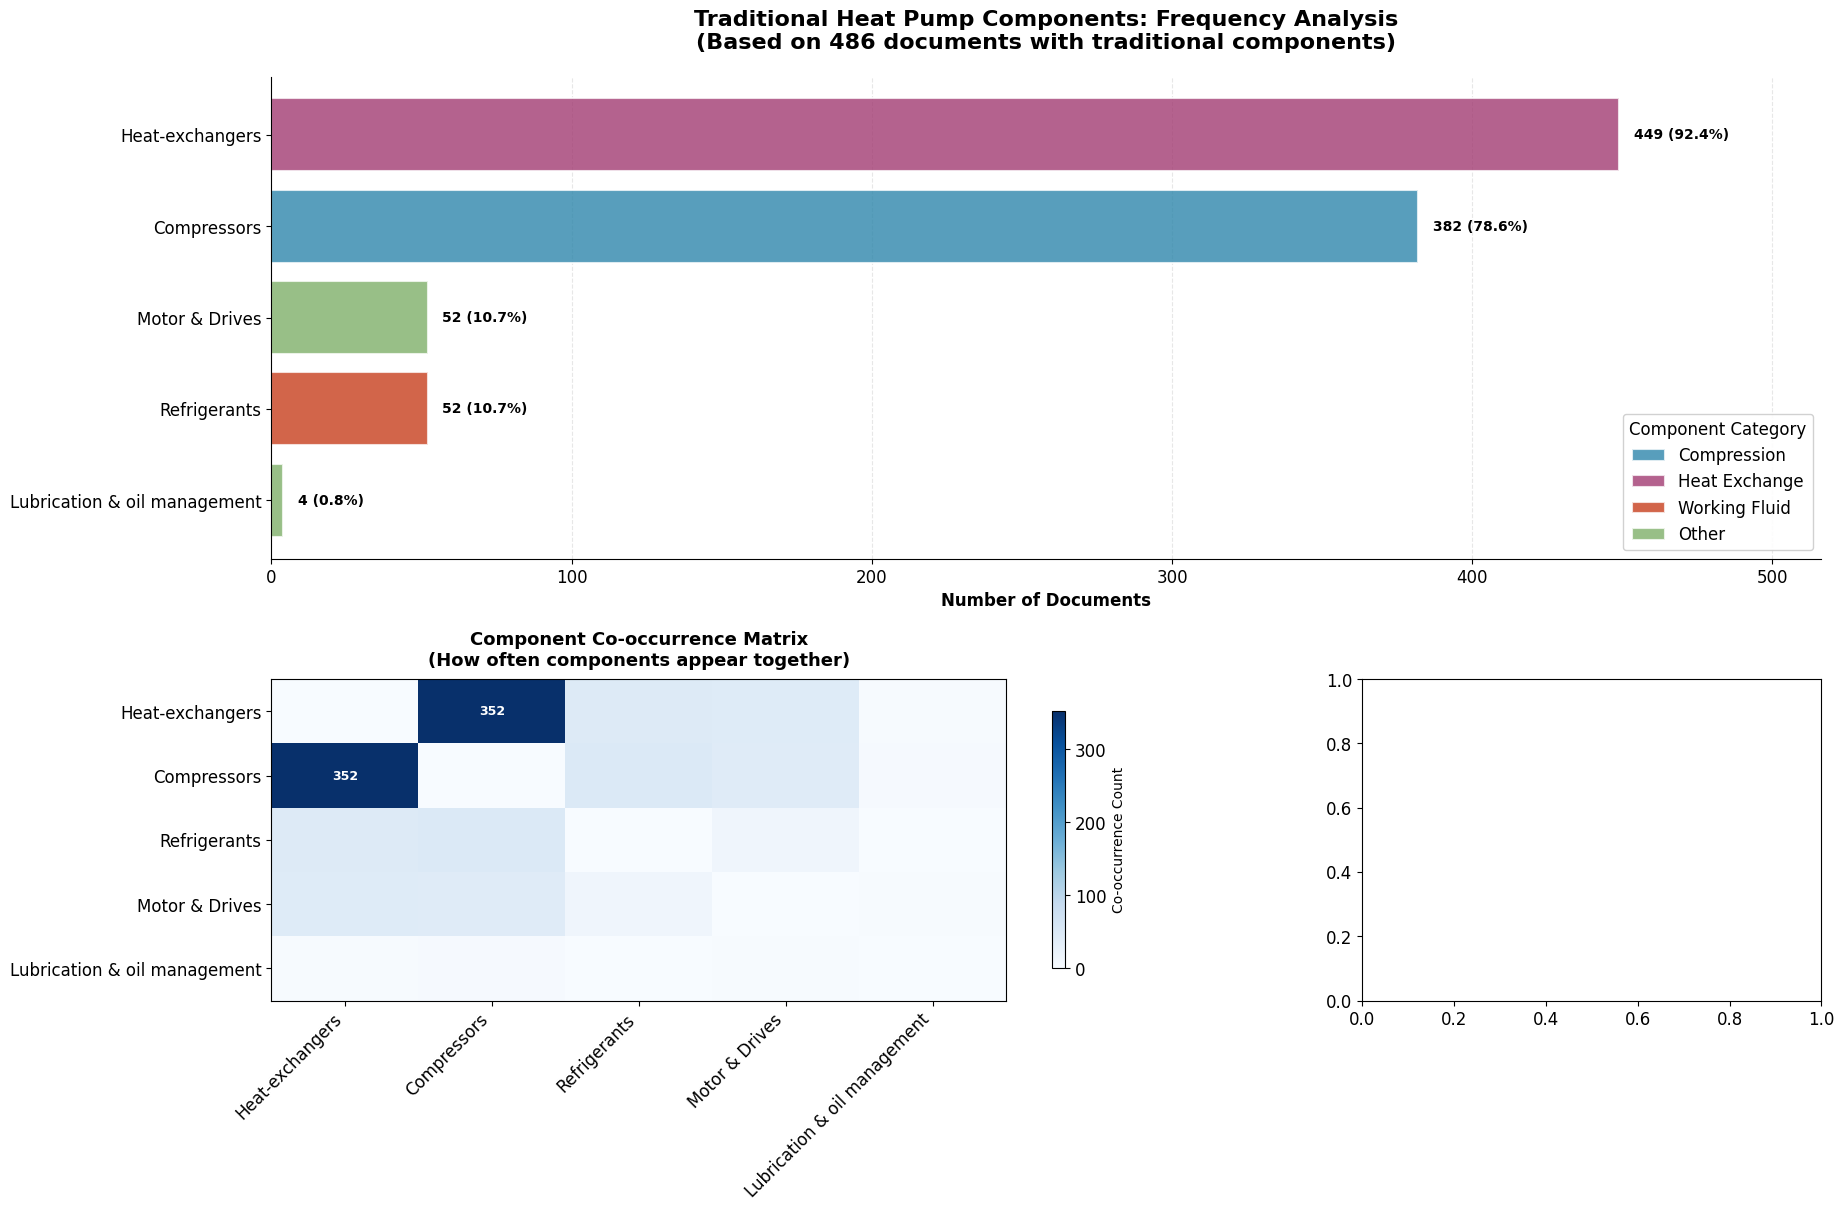

In [46]:
# ================================
# CELL 15: Create Plot 3 - Traditional Components Analysis
# ================================
print("\n" + "="*50)
print("🎨 CREATING PLOT 3: TRADITIONAL COMPONENTS DEEP DIVE")
print("="*50)

# Create figure with subplots
fig = plt.figure(figsize=(20, 12))

# Define grid layout
gs = fig.add_gridspec(2, 2, height_ratios=[3, 2], width_ratios=[2, 1], 
                     hspace=0.3, wspace=0.25)

# Subplot 1: Main bar chart of component frequencies
ax1 = fig.add_subplot(gs[0, :])

# Create color mapping for categories
category_colors = {
    'Compression': '#2E86AB',
    'Heat Exchange': '#A23B72', 
    'Flow Control': '#F18F01',
    'Working Fluid': '#C73E1D',
    'Auxiliary': '#563E7C',
    'Other': '#7FB069'
}

# Sort components by count
components_df_sorted = components_df.sort_values('Count', ascending=True)

# Create horizontal bar chart
bars = ax1.barh(range(len(components_df_sorted)), 
                components_df_sorted['Count'],
                color=[category_colors[cat] for cat in components_df_sorted['Category']],
                alpha=0.8,
                edgecolor='white',
                linewidth=1.5)

# Customize the plot
ax1.set_yticks(range(len(components_df_sorted)))
ax1.set_yticklabels(components_df_sorted['Component'])
ax1.set_xlabel('Number of Documents', fontsize=12, fontweight='bold')
ax1.set_title(f'Traditional Heat Pump Components: Frequency Analysis\n' +
              f'(Based on {TRAD_DOC_COUNT} documents with traditional components)',
              fontsize=16, fontweight='bold', pad=20)

# Add value labels
for i, (idx, row) in enumerate(components_df_sorted.iterrows()):
    ax1.text(row['Count'] + TRAD_DOC_COUNT*0.01, i,
             f"{row['Count']} ({row['Percentage']:.1f}%)",
             ha='left', va='center', fontsize=10, fontweight='bold')

# Add grid and styling
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(0, components_df_sorted['Count'].max() * 1.15)

# Add category legend
legend_elements = [plt.Rectangle((0,0),1,1, fc=color, alpha=0.8, edgecolor='white', linewidth=1.5) 
                  for cat, color in category_colors.items() if cat in components_df['Category'].values]
legend_labels = [cat for cat in category_colors.keys() if cat in components_df['Category'].values]
ax1.legend(legend_elements, legend_labels, loc='lower right', 
          title='Component Category', framealpha=0.9)

# Subplot 2: Co-occurrence heatmap
ax2 = fig.add_subplot(gs[1, 0])

# Create heatmap of component relationships
im = ax2.imshow(co_occurrence_matrix.values, cmap='Blues', aspect='auto')

# Set labels
ax2.set_xticks(range(len(top_component_names)))
ax2.set_xticklabels(top_component_names, rotation=45, ha='right')
ax2.set_yticks(range(len(top_component_names)))
ax2.set_yticklabels(top_component_names)

# Add value annotations for significant co-occurrences
threshold = co_occurrence_matrix.values.max() * 0.2  # Show values > 20% of max
for i in range(len(top_component_names)):
    for j in range(len(top_component_names)):
        value = co_occurrence_matrix.values[i, j]
        if value > threshold and i != j:
            text_color = 'white' if value > co_occurrence_matrix.values.max() * 0.6 else 'black'
            ax2.text(j, i, str(value), ha='center', va='center',
                    color=text_color, fontsize=9, fontweight='bold')

ax2.set_title('Component Co-occurrence Matrix\n(How often components appear together)',
              fontsize=13, fontweight='bold', pad=10)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label('Co-occurrence Count', fontsize=10)

# Subplot 3: Category distribution pie chart
ax3 = fig.add_subplot(gs[1, 1])

# Prepare data for pie chart
category_counts = components_df.groupby('Category')['Count'].sum()
category_percentages = category_counts / category_counts.sum() * 100

# Create pie chart
colors = [category_colors[cat] for cat in category_counts.index]
wedges, texts, autotexts = ax3.pie(category_counts.values, 
                                   labels=category_counts.index,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   alpha=0.8)

# Customize pie chart
ax3.set_title('Distribution by Component Category\n(Based on top components)',
              fontsize=13, fontweight='bold', pad=10)

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Overall figure adjustments
plt.suptitle(f'Traditional Heat Pump Components: Comprehensive Analysis',
             fontsize=18, fontweight='bold', y=0.98)

# Add source note
fig.text(0.02, 0.02,
         f'Source: Analysis of {len(df)} heat pump innovation documents. ' +
         f'{TRAD_DOC_COUNT} documents ({TRAD_DOC_COUNT/len(df)*100:.1f}%) contain traditional components.',
         fontsize=10, style='italic', alpha=0.7)

plt.tight_layout()

print("✅ Plot 3 created successfully!")
print("📊 Visualizations include:")
print("   1. Component frequency analysis (main chart)")
print("   2. Component co-occurrence patterns (heatmap)")
print("   3. Category distribution (pie chart)")

# Show the plot
plt.show()

In [47]:
# ================================
# CELL 16: Generate Innovation Insights from Traditional Components
# ================================
print("\n" + "="*50)
print("💡 GENERATING INNOVATION INSIGHTS FROM TRADITIONAL COMPONENTS")
print("="*50)

# Calculate key metrics
top_3_components = component_counts.most_common(3)
top_component_name = top_3_components[0][0] if top_3_components else "Unknown"
top_component_percentage = (top_3_components[0][1] / TRAD_DOC_COUNT * 100) if top_3_components else 0

# Compression technology dominance
compression_mentions = sum(count for comp, count in component_counts.items() 
                          if 'compress' in comp.lower())
compression_percentage = compression_mentions / TRAD_DOC_COUNT * 100

# Heat exchange focus
heat_exchange_mentions = sum(count for comp, count in component_counts.items() 
                           if any(term in comp.lower() for term in ['heat-exchang', 'evaporat', 'condens']))
heat_exchange_percentage = heat_exchange_mentions / TRAD_DOC_COUNT * 100

# Component diversity
unique_components = len(component_counts)
avg_components_per_doc = len(all_trad_components) / TRAD_DOC_COUNT

# Co-occurrence insights
max_co_occurrence = co_occurrence_matrix.values.max()
most_connected_component = co_occurrence_matrix.sum(axis=1).idxmax()
connectivity_score = co_occurrence_matrix.sum(axis=1).max()

print(f"🔍 KEY INSIGHTS:")
print("-" * 20)
print(f"1. Component Focus:")
print(f"   - {top_component_name} dominates with {top_3_components[0][1]} mentions ({top_component_percentage:.1f}%)")
print(f"   - Top 3 components account for {sum(c[1] for c in top_3_components)/len(all_trad_components)*100:.1f}% of all mentions")

print(f"\n2. Technology Categories:")
print(f"   - Compression technologies: {compression_percentage:.1f}% of documents")
print(f"   - Heat exchange systems: {heat_exchange_percentage:.1f}% of documents")

print(f"\n3. Innovation Patterns:")
print(f"   - {unique_components} unique traditional components identified")
print(f"   - Average {avg_components_per_doc:.1f} components per document")
print(f"   - Most integrated component: {most_connected_component} (appears with {connectivity_score:.0f} other components)")

# Refrigerant insights
refrigerant_mentions = component_counts.get('Refrigerants', 0) + component_counts.get('refrigerants', 0)
refrigerant_percentage = refrigerant_mentions / TRAD_DOC_COUNT * 100
print(f"\n4. Refrigerant Focus:")
print(f"   - {refrigerant_mentions} documents mention refrigerants ({refrigerant_percentage:.1f}%)")
print(f"   - {'High' if refrigerant_percentage > 30 else 'Moderate' if refrigerant_percentage > 15 else 'Limited'} focus on working fluid innovation")

# System integration insights
high_integration_docs = sum(1 for comps in trad_docs['trad_components_clean'] if len(comps) >= 3)
integration_percentage = high_integration_docs / TRAD_DOC_COUNT * 100
print(f"\n5. System Integration:")
print(f"   - {high_integration_docs} documents integrate 3+ components ({integration_percentage:.1f}%)")
print(f"   - {'Strong' if integration_percentage > 50 else 'Moderate' if integration_percentage > 30 else 'Limited'} focus on system-level innovation")

print("\n✅ Innovation insights generated!")


💡 GENERATING INNOVATION INSIGHTS FROM TRADITIONAL COMPONENTS
🔍 KEY INSIGHTS:
--------------------
1. Component Focus:
   - Heat-exchangers dominates with 449 mentions (92.4%)
   - Top 3 components account for 94.0% of all mentions

2. Technology Categories:
   - Compression technologies: 78.6% of documents
   - Heat exchange systems: 92.4% of documents

3. Innovation Patterns:
   - 5 unique traditional components identified
   - Average 1.9 components per document
   - Most integrated component: Compressors (appears with 447 other components)

4. Refrigerant Focus:
   - 52 documents mention refrigerants (10.7%)
   - Limited focus on working fluid innovation

5. System Integration:
   - 68 documents integrate 3+ components (14.0%)
   - Limited focus on system-level innovation

✅ Innovation insights generated!


In [48]:
# ================================
# CELL 17: Save Plot 3 and Comprehensive Analysis
# ================================
print("\n" + "="*50)
print("💾 SAVING PLOT 3: TRADITIONAL COMPONENTS ANALYSIS")
print("="*50)

# Use the same output directory
output_dir = Path("/home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5")

# Define file paths for Plot 3
png_path_plot3 = output_dir / "chapter5_plot3_traditional_components.png"
pdf_path_plot3 = output_dir / "chapter5_plot3_traditional_components.pdf"
csv_path_plot3 = output_dir / "chapter5_traditional_components_data.csv"
matrix_csv_path = output_dir / "chapter5_component_cooccurrence_matrix.csv"
summary_path_plot3 = output_dir / "chapter5_plot3_summary.txt"

# Save the plot
fig.savefig(png_path_plot3, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
fig.savefig(pdf_path_plot3, bbox_inches='tight', facecolor='white')

print("✅ Plot 3 saved as:")
print(f"   📊 {png_path_plot3} (high-res for thesis)")
print(f"   📊 {pdf_path_plot3} (vector format)")

# Save the component data
components_df.to_csv(csv_path_plot3, index=False)
co_occurrence_matrix.to_csv(matrix_csv_path)
print(f"   📋 {csv_path_plot3} (component frequency data)")
print(f"   📋 {matrix_csv_path} (co-occurrence matrix)")

# Create adaptive summary for thesis
def interpret_component_focus(percentage):
    if percentage >= 80:
        return "overwhelming dominance"
    elif percentage >= 60:
        return "strong dominance"
    elif percentage >= 40:
        return "significant focus"
    elif percentage >= 20:
        return "moderate emphasis"
    else:
        return "limited attention"

def interpret_diversity(unique_count, avg_per_doc):
    if unique_count >= 20 and avg_per_doc >= 3:
        return "high diversity and complex system integration"
    elif unique_count >= 15 or avg_per_doc >= 2.5:
        return "moderate diversity with multi-component focus"
    else:
        return "limited diversity suggesting specialized innovation"

# Generate summary text
summary_text_plot3 = f"""
CHAPTER 5 - PLOT 3 SUMMARY FOR THESIS WRITING:
Traditional Heat Pump Components Deep Dive

Dataset: {len(df)} heat pump innovation documents analyzed
Traditional component focus: {TRAD_DOC_COUNT} documents ({TRAD_DOC_COUNT/len(df)*100:.1f}%)
Total component mentions: {len(all_trad_components)}
Unique components identified: {unique_components}

KEY FINDINGS - COMPONENT ANALYSIS:

1. Component Frequency Distribution:
   - {top_component_name}: {top_3_components[0][1]} mentions ({top_component_percentage:.1f}% of traditional component docs)
   - Top 3 components: {', '.join([f"{comp[0]} ({comp[1]})" for comp in top_3_components])}
   - Average components per document: {avg_components_per_doc:.1f}

2. Technology Category Breakdown:
   - Compression technologies: {compression_percentage:.1f}% of documents
   - Heat exchange systems: {heat_exchange_percentage:.1f}% of documents
   - Refrigerant/working fluid: {refrigerant_percentage:.1f}% of documents

3. Innovation Patterns:
   - Component diversity: {interpret_diversity(unique_components, avg_components_per_doc)}
   - System integration: {high_integration_docs} documents ({integration_percentage:.1f}%) integrate 3+ components
   - Most integrated component: {most_connected_component} (co-occurs with {connectivity_score:.0f} others)

4. Co-occurrence Insights:
   - Maximum co-occurrence frequency: {max_co_occurrence}
   - Top component pair: {pair_counts.most_common(1)[0][0] if pair_counts else 'N/A'}
   - Network density: {'High' if co_occurrence_matrix.values.mean() > 5 else 'Moderate' if co_occurrence_matrix.values.mean() > 2 else 'Low'}

KEY THESIS ARGUMENTS SUPPORTED:

1. Technology Focus:
   - {interpret_component_focus(compression_percentage)} on compression technology ({compression_percentage:.1f}%)
   - Heat exchange receives {'comparable' if abs(heat_exchange_percentage - compression_percentage) < 10 else 'less'} attention ({heat_exchange_percentage:.1f}%)
   - {'Gap' if refrigerant_percentage < 20 else 'Growing focus'} in refrigerant innovation ({refrigerant_percentage:.1f}%)

2. Innovation Characteristics:
   - {'Incremental' if top_component_percentage > 70 else 'Distributed'} innovation pattern across components
   - {'Strong' if integration_percentage > 50 else 'Moderate' if integration_percentage > 30 else 'Limited'} systems thinking in component integration
   - {'Mature' if unique_components < 15 else 'Diverse'} component ecosystem

3. Research Implications:
   - {'Over-concentration' if top_component_percentage > 60 else 'Balanced focus'} on {top_component_name}
   - {'Opportunity' if refrigerant_percentage < 30 else 'Active development'} in alternative refrigerants
   - {'Need for' if integration_percentage < 40 else 'Progress in'} holistic system design approaches

Narrative for Chapter 5.1 (Traditional Components Section):

The analysis of traditional heat pump components reveals a technology landscape with {interpret_component_focus(top_component_percentage)} 
on {top_component_name.lower()} ({top_component_percentage:.1f}%), reflecting the industry's prioritization of 
{'core efficiency improvements' if 'compress' in top_component_name.lower() else 'heat transfer optimization' if 'heat' in top_component_name.lower() else 'system optimization'}.

The identification of {unique_components} unique traditional components across {TRAD_DOC_COUNT} documents indicates 
{interpret_diversity(unique_components, avg_components_per_doc)}. With an average of {avg_components_per_doc:.1f} components 
per innovation document, the field demonstrates {'a holistic approach to system design' if avg_components_per_doc > 2.5 else 'focused component-specific improvements'}.

Component co-occurrence analysis reveals that {most_connected_component} serves as a critical integration point, 
appearing alongside {connectivity_score:.0f} other components. This suggests that {'system-level thinking is emerging' if connectivity_score > 20 else 'component optimization remains somewhat siloed'} 
in heat pump innovation.

The {'limited' if refrigerant_percentage < 20 else 'moderate' if refrigerant_percentage < 35 else 'significant'} attention to refrigerants 
({refrigerant_percentage:.1f}%) {'presents an innovation gap' if refrigerant_percentage < 20 else 'shows growing awareness'} 
regarding environmental impact and performance optimization through working fluid selection.

Strategic Implications:
1. {'Diversification needed beyond' if top_component_percentage > 60 else 'Continue balanced approach to'} {top_component_name.lower()}
2. {'Increase focus on' if refrigerant_percentage < 30 else 'Maintain momentum in'} refrigerant alternatives
3. {'Promote' if integration_percentage < 40 else 'Leverage existing'} system integration approaches
4. Address component gaps in {[cat for cat in category_counts.index if category_counts[cat]/category_counts.sum() < 0.1]}

Connection to Circular Economy (Chapter 6):
- Traditional component focus suggests opportunities for circular design integration
- High component diversity enables modular approaches to serviceability
- Current innovation patterns may need reorientation toward end-of-life considerations

Next steps: Proceed to additional analysis or Chapter 5.2 (Material Circularity Evaluation)
"""

# Save the summary
with open(summary_path_plot3, 'w') as f:
    f.write(summary_text_plot3)

print(f"   📝 {summary_path_plot3} (comprehensive component analysis)")
print(f"\n✅ All Plot 3 files saved successfully to:")
print(f"📁 {output_dir}")

print("\n" + "="*50)
print("🎯 PLOT 3 COMPLETE - TRADITIONAL COMPONENTS DEEP DIVE")
print("="*50)
print("✅ Multi-panel visualization created and saved")
print("📊 Component frequency and co-occurrence data exported")
print("📝 Adaptive thesis summary generated")
print("🔍 Key insights: {0} dominance ({1:.1f}%), {2} unique components, {3:.1f}% system integration".format(
    top_component_name, top_component_percentage, unique_components, integration_percentage))
print("⏭️ Ready for next analysis or writing")


💾 SAVING PLOT 3: TRADITIONAL COMPONENTS ANALYSIS
✅ Plot 3 saved as:
   📊 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_plot3_traditional_components.png (high-res for thesis)
   📊 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_plot3_traditional_components.pdf (vector format)
   📋 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_traditional_components_data.csv (component frequency data)
   📋 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_component_cooccurrence_matrix.csv (co-occurrence matrix)
   📝 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5/chapter5_plot3_summary.txt (comprehensive component analysis)

✅ All Plot 3 files saved successfully to:
📁 /home/pascualdiego/projects/DiscoveryHP/outputs/Chapter 5

🎯 PLOT 3 COMPLETE - TRADITIONAL COMPONENTS DEEP DIVE
✅ Multi-panel visualization created and saved
📊 Component frequency and co-occurrence data exported
📝 Adaptive thesis summary generated
🔍 Key